In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import ast
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal
import requests

In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

In [3]:
random = pd.read_pickle('../2023-08-06_19-16-43_random_fold_ordering_14685-fixed-rn-seeds.pkl')

In [5]:
# best at the moment
batm = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3142.pkl')

In [ ]:
# cumiter = algorithm iteration number
# folditer = fold injection order

## cpds_cumiter

In [6]:
print(max(random.cpds_cumiter.values()))
print(max(batm.cpds_cumiter.values()))

590
985


4318


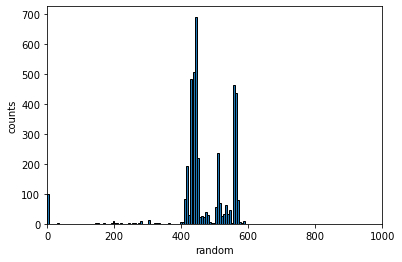

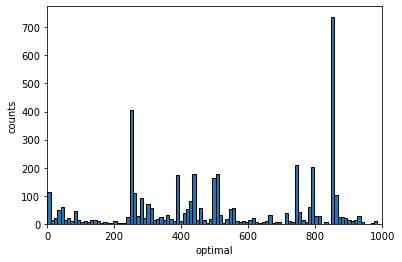

In [7]:
# cpds_cumiter: cmpd vs. iter# when cmpd was discovered

print(len(batm.cpds_cumiter))
histogram(random.cpds_cumiter, bins=100, x_range=[0,1000], x_axis='random')
histogram(batm.cpds_cumiter, bins=100, x_range=[0,1000], x_axis='optimal')

In [8]:
cumiter2cmpd_random = {}
for c, order in random.cpds_cumiter.items():
    if order not in cumiter2cmpd_random.keys():
        cumiter2cmpd_random[order] = [c]
    else:
        cumiter2cmpd_random[order].append(c)
print(len(cumiter2cmpd_random))

cumiter2cmpd = {}
for c, order in batm.cpds_cumiter.items():
    if order not in cumiter2cmpd.keys():
        cumiter2cmpd[order] = [c]
    else:
        cumiter2cmpd[order].append(c)
print(len(cumiter2cmpd))

197
651


In [9]:
len(cumiter2cmpd[0])  # seed

80

In [10]:
cumiter2cmpdCumm_random = {}
cumm = 0
for i in range(0, max(random.cpds_cumiter.values())): 
    if i in cumiter2cmpd_random.keys():
        cumm += len(cumiter2cmpd_random[i])
    cumiter2cmpdCumm_random[i] = cumm 

cumiter2cmpdCumm = {}
cumm = 0
for i in range(0, max(batm.cpds_cumiter.values())): 
    if i in cumiter2cmpd.keys():
        cumm += len(cumiter2cmpd[i])
    cumiter2cmpdCumm[i] = cumm

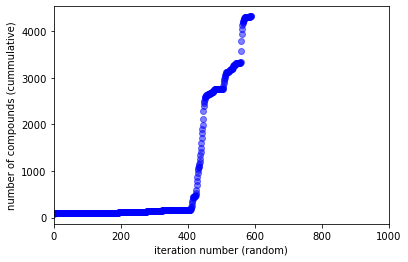

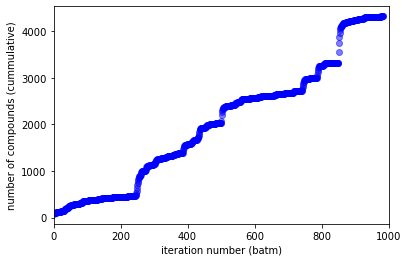

In [11]:
plt.scatter(cumiter2cmpdCumm_random.keys(), cumiter2cmpdCumm_random.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (random)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

plt.scatter(cumiter2cmpdCumm.keys(), cumiter2cmpdCumm.values(), marker='o', color='b', alpha = 0.5, label='Data Points', zorder=2)
plt.xlabel('iteration number (batm)')
plt.ylabel('number of compounds (cummulative)')
plt.xlim([0, 1000])
# plt.savefig('scatter.png')
plt.show()

## cpds_folditer

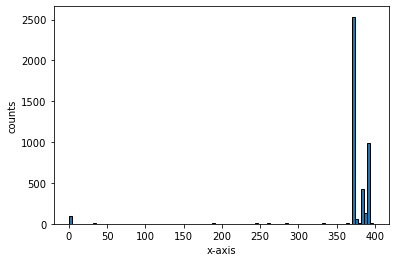

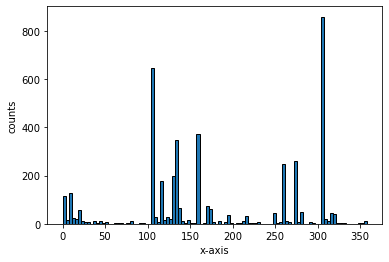

In [12]:
# cpds_folditer: cmpd vs. fold order (0-398) when cmpd was discovered
histogram(random.cpds_folditer, bins=100)
histogram(batm.cpds_folditer, bins=100)

In [13]:
fo2cmpd_random = {}
for c, order in random.cpds_folditer.items():
    if order not in fo2cmpd_random.keys():
        fo2cmpd_random[order] = [c]
    else:
        fo2cmpd_random[order].append(c)
print(len(fo2cmpd_random))

fo2cmpd = {}
for c, order in batm.cpds_folditer.items():
    if order not in fo2cmpd.keys():
        fo2cmpd[order] = [c]
    else:
        fo2cmpd[order].append(c)
print(len(fo2cmpd))

35
173


In [14]:
fo2cmpd_random.keys()

dict_keys([0, 1, 33, 141, 147, 166, 189, 191, 201, 211, 230, 240, 246, 259, 261, 283, 300, 305, 333, 366, 373, 375, 378, 379, 380, 381, 384, 385, 387, 388, 390, 392, 394, 397, 398])

In [15]:
fo2cmpdCumm_random = {}
cumm = 0
for i in range(0, max(random.cpds_folditer.values())): 
    if i in fo2cmpd_random.keys():  # this iter# exists in fo2cmpd_random
        cumm += len(fo2cmpd_random[i])  # add the #cmpds discovered
    fo2cmpdCumm_random[i] = cumm 

fo2cmpdCumm = {}
cumm = 0
for i in range(0, max(batm.cpds_folditer.values())): 
    if i in fo2cmpd.keys():
        cumm += len(fo2cmpd[i])
    fo2cmpdCumm[i] = cumm

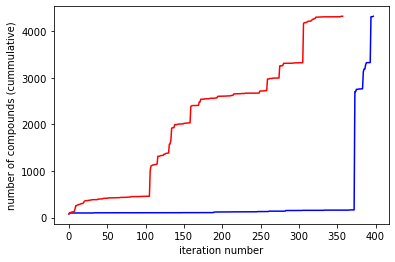

In [16]:
plt.plot(fo2cmpdCumm_random.keys(), fo2cmpdCumm_random.values(), color='b', alpha = 1,zorder=2)
plt.plot(fo2cmpdCumm.keys(), fo2cmpdCumm.values(), color='r', alpha = 1, zorder=2)
plt.xlabel('iteration number')
plt.ylabel('number of compounds (cummulative)')
plt.show()

# recruited for what?

In [17]:
def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX
            
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)
    
def get_reactions_for_compound(compound_id):
    response = requests.get(f'https://rest.kegg.jp/link/reaction/{compound_id}')
    lines = response.text.split('\n')
    
    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    return reactions

In [18]:
x2O2rnFrac = csv2dict('../data/assets/xgroup2/xgroup2O2rnFrac.csv')

In [19]:
O2rnsKEGG = get_reactions_for_compound('C00007')

ConnectionError: HTTPSConnectionPool(host='rest.kegg.jp', port=443): Max retries exceeded with url: /link/reaction/C00007 (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7fbc4d0ba730>: Failed to establish a new connection: [Errno 60] Operation timed out'))

In [ ]:
with open('../data/assets/reaction_iteration_O2_ablation.csv', 'r') as csv_file:
    csv_reader = csv.reader(csv_file)
    
    # Skip the header row
    next(csv_reader)
    
    rns_unreached_wo_O2 = []
    rns_unreached_wo_O2_v = []
    
    for row in csv_reader:
        if '' in row:
            if row[0][-2] != 'v':  # exclude reactions with "v"
                if row[0].startswith('R0') or row[0].startswith('R1'):
                    rns_unreached_wo_O2.append(row[0])
                else:
                    print(row[0])
            else:
                if row[0].endswith('v1'):  # rescue 'v1' because this file does not have "original" w/o version num
                    rns_unreached_wo_O2.append(row[0][:-3])
                    rns_unreached_wo_O2_v.append(row[0])
                else:
                    rns_unreached_wo_O2_v.append(row[0])

## checking why some later folds do not add any reactions 

In [ ]:
# add the extra direct O2 reactions from X5039
for rn in ['R09492', 'R00081', 'R00082', 'R10444']:
    rns_unreached_wo_O2.append(rn)

In [ ]:
# ??? there are folds added later, with reactions that are NOT added to network => missing SMs?
for r in ['R09492', 'R00081', 'R00082', 'R10444']:
    print(r in batm.rns_cumiter.keys(), r in rn2rules.keys())

In [ ]:
# R09492 = '2 Menaquinol + Oxygen + n H+ <=> 2 Menaquinone + 2 H2O + n H+'
#        =  2 C05819 + C00007 + n C00080 <=> 2 C00828 + 2 C00001 + n C00080

In [ ]:
'C05819' in batm.cpds_cumiter.keys()  # exists...

In [ ]:
'C00828' in batm.cpds_cumiter.keys()  # also exists => not added because it doesn't add anything new?

## back to analysis

In [ ]:
O2_direct_rn = set(rns_unreached_wo_O2) & set(O2rnsKEGG)
O2_indirect_rn = set(rns_unreached_wo_O2) - set(O2rnsKEGG)
len(O2_direct_rn), len(O2_indirect_rn), len(set(rns_unreached_wo_O2))

In [ ]:
# 1 is spontaneous
for rn, i in batm.rns_folditer.items():
    if i == 1:
        print(rn, rn2rules.get(rn, 'not in rn2rules'), rn in O2_direct_rn)

In [ ]:
# 2 is X2002
for rn, i in batm.rns_folditer.items():
    if i == 2:
        print(rn, rn2rules.get(rn, 'not in rn2rules'), rn in O2_direct_rn)

In [ ]:
# 3 is X1
for rn, i in batm.rns_folditer.items():
    if i == 3:
        print(rn, rn2rules.get(rn, 'not in rn2rules'), rn in O2_direct_rn)

In [ ]:
max(batm.rns_folditer.values())

In [ ]:
max(batm.folds_folditer.values())

### account for multiple injections

In [ ]:
iter2folds = {}
for fold, i in batm.folds_folditer.items():
    if i not in iter2folds.keys():
        iter2folds[i] = []
    iter2folds[i].append(fold)

In [ ]:
iter2folds

In [ ]:
fold2recruit = {}

O2d = 0
O2i = 0
total = 0

for i, folds in iter2folds.items():  # iter: [folds]
    b_total = total
    b_O2d = O2d
    b_O2i = O2i
        
    for rn, ii in batm.rns_folditer.items():  # rn : fold injection step [1:369]
        if ii == i:  # collect all reactions introduced by that step
            total += 1
            
            # direct O2
            if rn in O2_direct_rn:
                O2d += 1
            if rn[:-3] in O2_direct_rn:  # actotal for v_1 etc.
                if rn[-1] == '1':
                    O2d += 1 
            
            # indirect O2
            if rn in O2_indirect_rn:
                O2i += 1
            if rn[:-3] in O2_indirect_rn:  # actotal for v_1 etc.
                if rn[-1] == '1':
                    O2i += 1 
    
    # add same total for all folds injected in that step
    for fold in folds:
        fold2recruit[fold] = [O2d, O2i, total, O2d-b_O2d, O2i-b_O2i, total-b_total, round(float(x2O2rnFrac.get(fold, '0.000')), 3)]

In [ ]:
fold2recruit

In [ ]:
plt.plot([v[0] for v in fold2recruit.values()], color='red')
plt.plot([v[1] for v in fold2recruit.values()], color='pink')
plt.plot([v[2] for v in fold2recruit.values()])
plt.ylabel('cummulative reaction count')
plt.show

In [ ]:
fold2recruitRatio = {}

for fold, recruit in fold2recruit.items():
    if recruit[5] != 0:
        fold2recruitRatio[fold] = (recruit[3] + recruit[4])/recruit[5]
    else:
        fold2recruitRatio[fold] = 0

In [ ]:
fold2recruitRatio

In [ ]:
histogram(fold2recruitRatio, bins=50)

# do the same, but with cumiter
after fold injection, multiple iterations of network expansion => let's only look at one iteration immediately after fold injection

In [22]:
batm.folds_cumiter  # fold:cumiter

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 3,
 '1': 7,
 '2487': 11,
 '2006': 15,
 '246': 16,
 '2003': 18,
 '218': 22,
 '2007': 40,
 '7525': 49,
 '304': 51,
 '12': 58,
 '11': 60,
 '10': 63,
 '109': 65,
 '210': 69,
 '7515': 73,
 '279': 77,
 '7577': 78,
 '3016': 86,
 '281': 92,
 '7542': 96,
 '7528': 99,
 '331': 101,
 '2011': 103,
 '301': 107,
 '7572': 108,
 '282': 109,
 '206': 116,
 '325': 119,
 '805': 123,
 '7527': 124,
 '62': 125,
 '7529': 126,
 '180': 127,
 '3691': 128,
 '4126': 129,
 '7560': 130,
 '7512': 134,
 '7518': 135,
 '7579': 136,
 '70': 138,
 '297': 139,
 '286': 140,
 '205': 142,
 '7554': 147,
 '4002': 148,
 '2004': 149,
 '7580': 150,
 '315': 151,
 '307': 153,
 '7561': 155,
 '5104': 158,
 '212': 159,
 '7517': 160,
 '7571': 161,
 '5': 162,
 '7510': 164,
 '2': 165,
 '387': 166,
 '7567': 167,
 '247': 169,
 '208': 171,
 '7516': 172,
 '7574': 173,
 '2484': 174,
 '185': 175,
 '103': 179,
 '2005': 180,
 '64': 183,
 '7573': 184,
 '2493': 185,
 '708': 186,
 '7552': 187,
 '328'

In [23]:
batm.folds_cumiter['3997']

848

In [24]:
cumiter2folds = {}
for fold, i in batm.folds_cumiter.items():
    if i not in cumiter2folds.keys():
        cumiter2folds[i] = []
    cumiter2folds[i].append(fold)

In [25]:
cumiter2folds

{0: ['fold_independent'],
 1: ['spontaneous'],
 3: ['2002'],
 7: ['1'],
 11: ['2487'],
 15: ['2006'],
 16: ['246'],
 18: ['2003'],
 22: ['218'],
 40: ['2007'],
 49: ['7525'],
 51: ['304'],
 58: ['12'],
 60: ['11'],
 63: ['10'],
 65: ['109'],
 69: ['210'],
 73: ['7515'],
 77: ['279'],
 78: ['7577'],
 86: ['3016'],
 92: ['281'],
 96: ['7542'],
 99: ['7528'],
 101: ['331'],
 103: ['2011'],
 107: ['301'],
 108: ['7572'],
 109: ['282'],
 116: ['206'],
 119: ['325'],
 123: ['805'],
 124: ['7527'],
 125: ['62'],
 126: ['7529'],
 127: ['180'],
 128: ['3691'],
 129: ['4126'],
 130: ['7560'],
 134: ['7512'],
 135: ['7518'],
 136: ['7579'],
 138: ['70'],
 139: ['297'],
 140: ['286'],
 142: ['205'],
 147: ['7554'],
 148: ['4002'],
 149: ['2004'],
 150: ['7580'],
 151: ['315'],
 153: ['307'],
 155: ['7561'],
 158: ['5104'],
 159: ['212'],
 160: ['7517'],
 161: ['7571'],
 162: ['5'],
 164: ['7510'],
 165: ['2'],
 166: ['387'],
 167: ['7567'],
 169: ['247'],
 171: ['208'],
 172: ['7516'],
 173: ['757

In [26]:
max(batm.rns_cumiter.values())

997

In [27]:
cumiter2rns = {}
for rn, i in batm.rns_cumiter.items():
    if i not in cumiter2rns.keys():
        cumiter2rns[i] = []
    cumiter2rns[i].append(rn)

In [28]:
cumiter2rns

{1: ['RZ_492',
  'RZ_340',
  'RZ_502',
  'R00338_v1',
  'RZ_388',
  'R03597',
  'RZ_510',
  'RZ_144',
  'R00412',
  'RZ_341',
  'RZ_5',
  'RZ_503',
  'RZ_493',
  'RZ_513',
  'RZ_424',
  'RZ_107',
  'RZ_3',
  'RZ_511',
  'R00476_v1',
  'RZ_423',
  'RZ_501',
  'RZ_507',
  'R00493',
  'RZ_508',
  'RZ_106',
  'R00218',
  'R00263',
  'RZ_515',
  'RZ_273',
  'RZ_514',
  'RZ_481',
  'R01339',
  'RZ_27',
  'RZ_506',
  'RZ_304',
  'RZ_480'],
 2: ['R04177',
  'R03693',
  'R00628',
  'R00477',
  'R03266',
  'R12185',
  'R00219',
  'R00347_v4',
  'R01336',
  'R00347_v1',
  'R08698',
  'R00347_v3',
  'R01854',
  'R00363',
  'R00268_v3',
  'R07316',
  'R00347_v2',
  'R03694'],
 5: ['R00430_gGTP_v1',
  'R00346',
  'R00200_gATP_v1',
  'R00430_gGTP_v2',
  'R00200_gATP_v2'],
 4: ['R00471_v1', 'R10283_v1', 'R00345_v2', 'RZ_383', 'R00345_v1'],
 3: ['R00479_v1', 'R00217_v3', 'R00217_v1', 'R00217_v2', 'R00470_v1'],
 6: ['R00320', 'R00584'],
 8: ['R09683_v1',
  'R09718_v3',
  'R00915',
  'R09717_v1',
  'R096

In [29]:
cumiter2rns.keys()

dict_keys([1, 2, 5, 4, 3, 6, 8, 9, 7, 10, 13, 12, 14, 15, 16, 17, 20, 21, 19, 27, 33, 35, 23, 29, 28, 34, 37, 36, 32, 39, 38, 30, 25, 31, 24, 45, 46, 40, 44, 47, 43, 48, 42, 41, 50, 49, 54, 52, 56, 53, 57, 55, 51, 58, 59, 61, 62, 60, 63, 64, 65, 66, 67, 68, 72, 70, 71, 76, 74, 77, 81, 80, 78, 85, 79, 83, 82, 84, 88, 89, 87, 90, 86, 91, 93, 95, 94, 97, 98, 96, 100, 99, 101, 102, 104, 106, 105, 114, 113, 115, 112, 110, 117, 116, 118, 121, 120, 122, 125, 126, 128, 133, 132, 131, 134, 137, 138, 139, 141, 140, 143, 146, 145, 142, 144, 148, 151, 152, 154, 157, 156, 160, 163, 164, 168, 169, 170, 173, 176, 177, 178, 181, 182, 184, 188, 190, 192, 193, 195, 196, 198, 199, 202, 201, 203, 204, 206, 205, 208, 213, 215, 219, 221, 222, 224, 226, 227, 228, 231, 233, 237, 239, 253, 254, 252, 245, 246, 264, 251, 262, 261, 250, 247, 255, 260, 249, 257, 263, 248, 273, 244, 256, 266, 258, 269, 242, 265, 259, 241, 274, 271, 243, 270, 268, 267, 240, 277, 280, 276, 279, 278, 275, 281, 284, 282, 283, 285, 286,

In [30]:
from collections import OrderedDict
# make sure the keys are in the right order
cumiter2rns = OrderedDict(sorted(cumiter2rns.items(), key=lambda x: int(x[0])))

In [31]:
cumiter2rns.keys()

odict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 74, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 104, 105, 106, 110, 112, 113, 114, 115, 116, 117, 118, 120, 121, 122, 125, 126, 128, 131, 132, 133, 134, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 148, 151, 152, 154, 156, 157, 160, 163, 164, 168, 169, 170, 173, 176, 177, 178, 181, 182, 184, 188, 190, 192, 193, 195, 196, 198, 199, 201, 202, 203, 204, 205, 206, 208, 213, 215, 219, 221, 222, 224, 226, 227, 228, 231, 233, 237, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286

## Check: does fold injection coincide with rn utilization?

### X3997

In [20]:
batm.folds_cumiter['3997']

848

In [32]:
cumiter2rns[batm.folds_cumiter['3997']+1]  # 848 + 1 = 849

['R03877', 'RZ_305']

In [33]:
set(x2rn['3997']) & set(cumiter2rns[batm.folds_cumiter['3997']+1])
# fold injection does NOT coincide with rn utilization

{'R03877'}

In [34]:
# cumiter2rns[batm.folds_cumiter['3997']]  # KeyError

In [35]:
set(x2rn['3997'])

{'R03877'}

### X146

In [36]:
batm.folds_cumiter['146']  # X146 is injected after X3997

867

In [37]:
set(x2rn['146']) & set(cumiter2rns[batm.folds_cumiter['146']+1])

set()

In [38]:
set(x2rn['146']) & set(cumiter2rns[batm.folds_cumiter['146']])
# fold injection coincides with rn utilization

{'R00031_v1',
 'R00045_v1',
 'R00058_v1',
 'R00080_v1',
 'R00731_v1',
 'R02078_v1',
 'R02363_v1',
 'R02383_v1',
 'R02950_v1',
 'R07224_v1',
 'R07225_v1',
 'R08005_v1',
 'R08008_v1',
 'R08009_v1',
 'R08010_v1'}

In [40]:
# check the cumiter immediately after X146 injection
set(cumiter2rns[batm.folds_cumiter['146']+1])
#  none of these are rn catalyzed by X146!

{'QUIN_SYN2', 'R02962', 'R08011', 'RZ_179', 'RZ_195', 'RZ_199', 'RZ_205'}

In [41]:
for rn in cumiter2rns[batm.folds_cumiter['146']+1]:
    print(rn2rules.get(rn, 0))

0
{frozenset({'spontaneous'})}
0
0
0
0
0


In [ ]:
print(set(x2rn['146']))

In [ ]:
print(set(cumiter2rns[batm.folds_cumiter['146']+1]))

### X228

In [ ]:
# X228 = SOD fold
# ['R00275', 'R00275_v3', 'R00275_v4', 'R00275_v2', 'R00275_v1']

In [ ]:
batm.rns_cumiter['R00275_v1'], batm.rns_cumiter['R00275_v2'], batm.rns_cumiter['R00275_v3'], batm.rns_cumiter['R00275_v4']

In [ ]:
batm.folds_cumiter['228']

In [ ]:
'R09518' in O2_direct_rn, 'R00148_v1' in O2_direct_rn

In [ ]:
rn2rules['R00275_v1']

In [ ]:
fold2recruit2 = {}

O2d = 0
O2i = 0
total = 0

for i, rns in cumiter2rns.items():  # 849: ['R03877', 'RZ_305'] 

    b_total = total
    b_O2d = O2d
    b_O2i = O2i

    for rn in rns:
        total += 1

        # direct O2
        if rn in O2_direct_rn:
            O2d += 1
        if rn[:-3] in O2_direct_rn:  # account for v_1 etc.
            if rn[-1] == '1':
                O2d += 1 

        # indirect O2
        if rn in O2_indirect_rn:
            O2i += 1
        if rn[:-3] in O2_indirect_rn:  # account for v_1 etc.
            if rn[-1] == '1':
                O2i += 1 

    if i-1 in cumiter2folds.keys():  # get fold injected immediately before rn discovery
        # add same total for all folds injected in that step
        folds = cumiter2folds[i-1]
        for fold in folds:
            fold2recruit2[fold] = [O2d, O2i, total, O2d-b_O2d, O2i-b_O2i, total-b_total, round(float(x2O2rnFrac.get(fold, '0.000')), 3), i]
    print(O2d, O2i, total, O2d-b_O2d, O2i-b_O2i, total-b_total, i)

In [ ]:
fold2recruit2

In [ ]:
fold2recruit2Ratio = {}

for fold, recruit in fold2recruit2.items():
    if recruit[5] != 0:
        fold2recruit2Ratio[fold] = (recruit[3] + recruit[4])/recruit[5]
    else:
        fold2recruit2Ratio[fold] = 0

# some folds are injected with ZERO reaction discovery immediately after
for fold in fold2recruit.keys():
    if fold not in fold2recruit2Ratio:
        fold2recruit2Ratio[fold] = 0

## are they significantly different? compare

In [ ]:
scatter(fold2recruitRatio, fold2recruit2Ratio)  # very different

# considering that fold injection does NOT always coincide with rn utilization,
let's stick with the first one - Ratio of all reactions discovered by that fold UNTIL next fold injection

In [ ]:
df_folds_folditer = pd.read_csv('../folds_folditer_optimal_1000runs.csv', index_col=0)
df_rns_folditer = pd.read_csv('../rns_folditer_optimal_1000runs.csv', index_col=0)

In [ ]:
df_folds_folditer.columns

In [ ]:
df_folds_folditer['36964']

In [ ]:
ratioDicts = []

# seeds = ['36964']
# for seed in seeds:
    
for seed in df_folds_folditer.columns:
    # create iter2folds
    iter2folds = {}
    fold_dict = df_folds_folditer[seed]
    rn_dict = df_rns_folditer[seed]

    for fold, i in fold_dict.items():
        if i not in iter2folds.keys():
            iter2folds[i] = []
        iter2folds[i].append(fold)

    # create fold2recruit
    fold2recruit = {}

    O2d = 0
    O2i = 0
    total = 0

    for i, folds in iter2folds.items():  # iter: [folds]
        b_total = total
        b_O2d = O2d
        b_O2i = O2i

        for rn, ii in rn_dict.items():  # rn : fold injection step [1:369]
            if ii == i:  # collect all reactions introduced by that step
                total += 1

                # direct O2
                if rn in O2_direct_rn:
                    O2d += 1
                if rn[:-3] in O2_direct_rn:  # actotal for v_1 etc.
                    if rn[-1] == '1':
                        O2d += 1 

                # indirect O2
                if rn in O2_indirect_rn:
                    O2i += 1
                if rn[:-3] in O2_indirect_rn:  # actotal for v_1 etc.
                    if rn[-1] == '1':
                        O2i += 1 

        # add same total for all folds injected in that step
        for fold in folds:
            fold2recruit[fold] = [O2d, O2i, total, O2d-b_O2d, O2i-b_O2i, total-b_total]

    # get Ratio
    fold2recruitRatio = {}
    for fold, recruit in fold2recruit.items():
        if recruit[5] != 0:
            fold2recruitRatio[fold] = [(recruit[3] + recruit[4])/recruit[5], recruit[3]/recruit[5], recruit[4]/recruit[5]]
        else:  # no fold incorporated after addition of this fold
            fold2recruitRatio[fold] = [0, 0, 0, 'none']
    ratioDicts.append(fold2recruitRatio)

In [ ]:
# make empty dict with fold as keys
fold2ratioAveBoth = {}
fold2ratioAveDirect = {}
fold2ratioAveIndirect = {}
fold2ratioNone = {}
for key in ratioDicts[0].keys():
    fold2ratioAveBoth[key] = []
    fold2ratioAveDirect[key] = []
    fold2ratioAveIndirect[key] = []
    fold2ratioNone[key] = []

# collect all ratios based on category
for d in ratioDicts:
    for key in d.keys():
        fold2ratioAveBoth[key].append(d[key][0])
        fold2ratioAveDirect[key].append(d[key][1])
        fold2ratioAveIndirect[key].append(d[key][2])
        try:
            fold2ratioNone[key].append(d[key][3])
        except:
            pass

In [ ]:
for key in fold2ratioAveBoth.keys():
    fold2ratioAveBoth[key] = sum(fold2ratioAveBoth[key])/len(fold2ratioAveBoth[key])
for key in fold2ratioAveBoth.keys():
    fold2ratioAveDirect[key] = sum(fold2ratioAveDirect[key])/len(fold2ratioAveDirect[key])
for key in fold2ratioAveBoth.keys():
    fold2ratioAveIndirect[key] = sum(fold2ratioAveIndirect[key])/len(fold2ratioAveIndirect[key])

In [ ]:
for key in fold2ratioAveBoth.keys():
    fold2ratioNone[key] = len(fold2ratioNone[key])

In [ ]:
fold2ratioNone

In [ ]:
fold2ratioAve = {}
for key in fold2ratioAveBoth.keys():
    fold2ratioAve[key] = [fold2ratioAveBoth[key], fold2ratioAveDirect[key], fold2ratioAveIndirect[key], fold2ratioNone[key]]

In [ ]:
for fold in fold2ratioAve.keys():
    print(fold, fold2ratioAve[fold], x2O2rnFrac.get(fold, 0))

# fold [both, direct, indirect, #none] X2O2rnFrac

In [ ]:
ignoreO2 = set()
learnO2 = set()
startO2 = set()
unknown = set()

for fold in fold2ratioAve.keys():
    if fold2ratioAve[fold][3] == 1000:
        unknown.add(fold)
    if fold2ratioAve[fold][0] > 0.5:
        startO2.add(fold)

print(len(startO2))
print(len(unknown))

# What are the early reactions?

In [ ]:
for r in cumiter2rns[300]:
    print(r, rn2eqn.get(r, 0), rn2rules.get(r, 0))